In [ ]:
import numpy as np

def generate_orbit(GM=1.0, dt=0.01, steps=1000):
    # initial conditions
    x, y, z = 1.0, 0.0,0.0
    vx, vy,vz = 0.0, 1.0,0.1

    trajectory = []

    for i in range(steps):
        t = i * dt
        r = np.sqrt(x**2+y**2+z**2)

        ax = -(GM*x)/r**3
        ay = -(GM*y)/r**3
        az = -(GM*z)/r**3

        # store current state
        trajectory.append([t, x, y, z, vx, vy, vz])

        # euler update — you fill these four lines
        x  = x+vx*dt
        y  = y+vy*dt
        z  = z+vz*dt
        vx = vx+ax*dt
        vy = vy+ay*dt
        vz = vz+az*dt

    return np.array(trajectory)

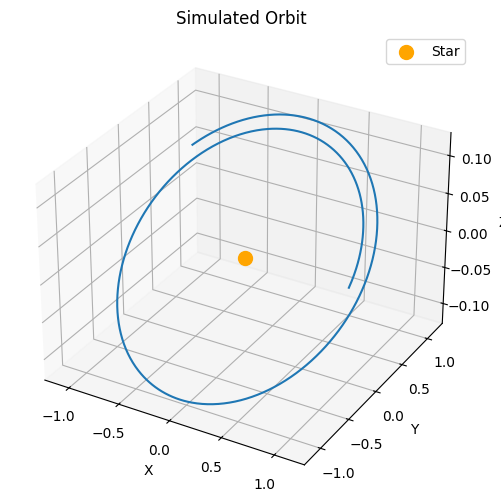

In [ ]:
import matplotlib.pyplot as plt

data = generate_orbit(GM=1.0, dt=0.01, steps=1000)

t   = data[:, 0]
x   = data[:, 1]
y   = data[:, 2]
z   = data[:, 3]
vx  = data[:, 4]
vy  = data[:, 5]
vz  = data[:, 6]

# plot the orbit shape
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot(x, y, z)
ax.scatter([0], [0], [0], color='orange', s=100, label='Star')
ax.set_title('Simulated Orbit')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()
plt.show()

In [ ]:
import torch
import torch.nn as nn
class VanillaNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(1, 128)
        self.layer2 = nn.Linear(128, 128)
        self.layer3 = nn.Linear(128, 128)
        self.layer4 = nn.Linear(128, 3)

    def forward(self, t):
        out1 = torch.tanh(self.layer1(t))
        out2 = torch.tanh(self.layer2(out1))
        out3 = torch.tanh(self.layer3(out2))
        return self.layer4(out3)

In [ ]:
data = generate_orbit(GM=1.0, dt=0.01, steps=1000)

t_data  = torch.tensor(data[:, 0], dtype=torch.float32).unsqueeze(1)
x_data  = torch.tensor(data[:, 1], dtype=torch.float32).unsqueeze(1)
y_data  = torch.tensor(data[:, 2], dtype=torch.float32).unsqueeze(1)
z_data  = torch.tensor(data[:, 3], dtype=torch.float32).unsqueeze(1)
# model and optimizer
model_vanilla  = VanillaNN()
optimizer = torch.optim.Adam(model_vanilla.parameters(), lr=1e-3)

# training loop
for epoch in range(20000):
    optimizer.zero_grad()

    # data loss
    pred      = model_vanilla(t_data)
    pred_x    = pred[:, 0:1]
    pred_y    = pred[:, 1:2]
    pred_z    = pred[:, 2:3]
    loss_data = ((pred_x - x_data)**2 + (pred_y - y_data)**2 + (pred_z - z_data)**2).mean()
    loss_data.backward()
    optimizer.step()

    if epoch % 2000 == 0:
        print(f"Epoch {epoch} | Data Loss: {loss_data.item():.4f} ")

Epoch 0 | Data Loss: 1.3706 
Epoch 2000 | Data Loss: 0.0001 
Epoch 4000 | Data Loss: 0.0000 
Epoch 6000 | Data Loss: 0.0001 
Epoch 8000 | Data Loss: 0.0000 
Epoch 10000 | Data Loss: 0.0000 
Epoch 12000 | Data Loss: 0.0001 
Epoch 14000 | Data Loss: 0.0001 
Epoch 16000 | Data Loss: 0.0001 
Epoch 18000 | Data Loss: 0.0002 


In [ ]:
import torch
import torch.nn as nn

class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(1, 128)
        self.layer2 = nn.Linear(128, 128)
        self.layer3 = nn.Linear(128, 128)
        self.layer4 = nn.Linear(128, 3)

    def forward(self, t):
        out1 = torch.tanh(self.layer1(t))
        out2 = torch.tanh(self.layer2(out1))
        out3 = torch.tanh(self.layer3(out2))
        return self.layer4(out3)

In [ ]:
def physics_loss(model, t, GM=1.0):
    coords = model(t)
    x = coords[:, 0:1]
    y = coords[:, 1:2]
    z = coords[:, 2:3]
    dx_dt = torch.autograd.grad(
        x, t,
        grad_outputs=torch.ones_like(x),
        create_graph=True
    )[0]

    dy_dt = torch.autograd.grad(
        y, t,
        grad_outputs=torch.ones_like(y),
        create_graph=True
    )[0]

    dz_dt = torch.autograd.grad(
        z, t,
        grad_outputs=torch.ones_like(z),
        create_graph=True
    )[0]

    d2x_dt2 = torch.autograd.grad(
        dx_dt, t,
        grad_outputs=torch.ones_like(dx_dt),
        create_graph=True
    )[0]

    d2y_dt2 = torch.autograd.grad(
        dy_dt, t,
        grad_outputs=torch.ones_like(dy_dt),
        create_graph=True
    )[0]

    d2z_dt2 = torch.autograd.grad(
        dz_dt, t,
        grad_outputs=torch.ones_like(dz_dt),
        create_graph=True
    )[0]


    r = torch.sqrt(x**2 + y**2+z**2)

    fx = -GM * x / r**3
    fy = -GM * y / r**3
    fz = -GM * z / r**3

    residual_x = d2x_dt2 - fx
    residual_y = d2y_dt2 - fy
    residual_z = d2z_dt2 - fz

    return (residual_x**2 + residual_y**2+residual_z**2).mean()

In [ ]:
# prepare data
data = generate_orbit(GM=1.0, dt=0.01, steps=1000)

t_data  = torch.tensor(data[:, 0], dtype=torch.float32).unsqueeze(1)
x_data  = torch.tensor(data[:, 1], dtype=torch.float32).unsqueeze(1)
y_data  = torch.tensor(data[:, 2], dtype=torch.float32).unsqueeze(1)
z_data  = torch.tensor(data[:, 3], dtype=torch.float32).unsqueeze(1)

# collocation points — random time points for physics loss
t_phys = torch.linspace(0, 20, 2000).unsqueeze(1).requires_grad_(True)
# model and optimizer
model   = PINN()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# training loop
for epoch in range(20000):
    optimizer.zero_grad()

    # data loss
    pred      = model(t_data)
    pred_x    = pred[:, 0:1]
    pred_y    = pred[:, 1:2]
    pred_z    = pred[:, 2:3]
    loss_data = ((pred_x - x_data)**2 + (pred_y - y_data)**2 +(pred_z - z_data)**2).mean()

    # physics loss
    loss_phys = physics_loss(model, t_phys)

    # total loss
    loss = loss_data + 0.01 * loss_phys

    loss.backward()
    optimizer.step()

    if epoch % 2000 == 0:
        print(f"Epoch {epoch} | Data Loss: {loss_data.item():.4f} | Physics Loss: {loss_phys.item():.4f}")

Epoch 0 | Data Loss: 1.2163 | Physics Loss: 1039.2231
Epoch 2000 | Data Loss: 0.0011 | Physics Loss: 0.0484
Epoch 4000 | Data Loss: 0.0001 | Physics Loss: 0.0239
Epoch 6000 | Data Loss: 0.0000 | Physics Loss: 0.0162
Epoch 8000 | Data Loss: 0.0003 | Physics Loss: 0.0150
Epoch 10000 | Data Loss: 0.0000 | Physics Loss: 0.0130
Epoch 12000 | Data Loss: 0.0019 | Physics Loss: 0.0118
Epoch 14000 | Data Loss: 0.0000 | Physics Loss: 0.0103
Epoch 16000 | Data Loss: 0.0001 | Physics Loss: 0.0092
Epoch 18000 | Data Loss: 0.0001 | Physics Loss: 0.0076


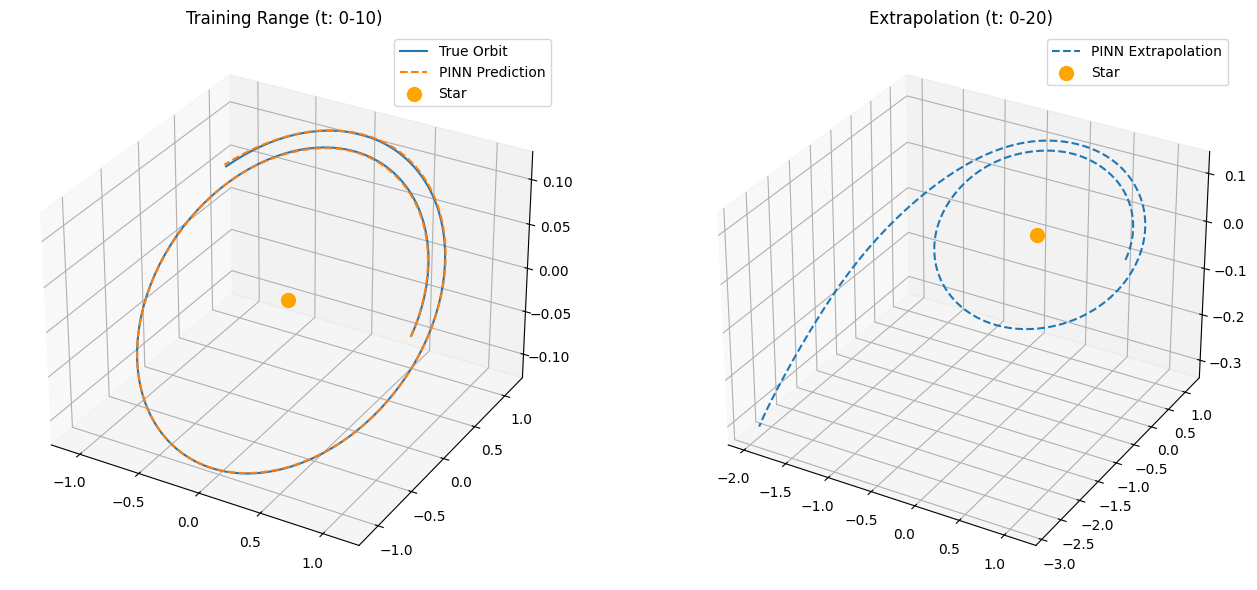

In [ ]:
model.eval()

t_test = torch.linspace(0, 10, 1000).unsqueeze(1)
t_extrap = torch.linspace(0, 20, 2000).unsqueeze(1)

with torch.no_grad():
    pred = model(t_test).numpy()
    pred_extrap = model(t_extrap).numpy()

fig = plt.figure(figsize=(14, 6))

# training range
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot(data[:, 1], data[:, 2], data[:, 3], label='True Orbit')
ax1.plot(pred[:, 0], pred[:, 1], pred[:, 2], '--', label='PINN Prediction')
ax1.scatter([0], [0], [0], color='orange', s=100, label='Star')
ax1.set_title('Training Range (t: 0-10)')
ax1.legend()

# extrapolation
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot(pred_extrap[:, 0], pred_extrap[:, 1], pred_extrap[:, 2], '--', label='PINN Extrapolation')
ax2.scatter([0], [0], [0], color='orange', s=100, label='Star')
ax2.set_title('Extrapolation (t: 0-20)')
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

def generate_orbit_verlet(GM=1.0, dt=0.01, steps=1000):
    x, y, z = 1.0, 0.0, 0.0
    vx, vy, vz = 0.0, 1.0, 0.1

    def compute_acc(x, y, z):
        r = np.sqrt(x**2 + y**2 + z**2)
        ax = -GM * x / r**3
        ay = -GM * y / r**3
        az = -GM * z / r**3
        return ax, ay, az

    trajectory = []
    for i in range(steps):
        t = i * dt

        ax, ay, az = compute_acc(x, y, z)

        x_new = x + vx*dt + 0.5*ax*dt**2
        y_new = y + vy*dt + 0.5*ay*dt**2
        z_new = z + vz*dt + 0.5*az*dt**2

        ax_new, ay_new, az_new = compute_acc(x_new, y_new, z_new)

        vx = vx + 0.5*(ax + ax_new)*dt
        vy = vy + 0.5*(ay + ay_new)*dt
        vz = vz + 0.5*(az + az_new)*dt

        x, y, z = x_new, y_new, z_new

        trajectory.append([t, x, y, z, vx, vy, vz])

    return np.array(trajectory)

In [ ]:
# Generate Velocity Verlet data
data_verlet = generate_orbit_verlet(GM=1.0, dt=0.01, steps=1000)

t_data  = torch.tensor(data_verlet[:, 0], dtype=torch.float32).unsqueeze(1)
x_data  = torch.tensor(data_verlet[:, 1], dtype=torch.float32).unsqueeze(1)
y_data  = torch.tensor(data_verlet[:, 2], dtype=torch.float32).unsqueeze(1)
z_data  = torch.tensor(data_verlet[:, 3], dtype=torch.float32).unsqueeze(1)

t_phys = torch.linspace(0, 20, 2000).unsqueeze(1).requires_grad_(True)

model_verlet = PINN()
optimizer = torch.optim.Adam(model_verlet.parameters(), lr=1e-3)

for epoch in range(20000):
    optimizer.zero_grad()

    pred = model_verlet(t_data)
    pred_x = pred[:, 0:1]
    pred_y = pred[:, 1:2]
    pred_z = pred[:, 2:3]

    loss_data = ((pred_x - x_data)**2 +
                 (pred_y - y_data)**2 +
                 (pred_z - z_data)**2).mean()

    loss_phys = physics_loss(model_verlet, t_phys)
    loss = loss_data + 0.01 * loss_phys

    loss.backward()
    optimizer.step()

    if epoch % 2000 == 0:
        print(f"Epoch {epoch} | Data Loss: {loss_data.item():.4f} | Physics Loss: {loss_phys.item():.4f}")

Epoch 0 | Data Loss: 1.0971 | Physics Loss: 207.3300
Epoch 2000 | Data Loss: 0.0004 | Physics Loss: 0.0360
Epoch 4000 | Data Loss: 0.0001 | Physics Loss: 0.0236
Epoch 6000 | Data Loss: 0.0001 | Physics Loss: 0.0204
Epoch 8000 | Data Loss: 0.0001 | Physics Loss: 0.0185
Epoch 10000 | Data Loss: 0.0001 | Physics Loss: 0.0149
Epoch 12000 | Data Loss: 0.0007 | Physics Loss: 0.0139
Epoch 14000 | Data Loss: 0.0005 | Physics Loss: 0.0110
Epoch 16000 | Data Loss: 0.0000 | Physics Loss: 0.0087
Epoch 18000 | Data Loss: 0.0001 | Physics Loss: 0.0075


In [ ]:

true_data = generate_orbit_verlet(GM=1.0, dt=0.01, steps=2000)
true_x = true_data[1000:, 1]
true_y = true_data[1000:, 2]
true_z = true_data[1000:, 3]

t_unseen = torch.linspace(10, 20, 1000).unsqueeze(1)
t_full   = torch.linspace(0, 20, 2000).unsqueeze(1)

with torch.no_grad():
    pred_vanilla_unseen = model_vanilla(t_unseen).numpy()
    pred_euler_unseen   = model(t_unseen).numpy()
    pred_verlet_unseen  = model_verlet(t_unseen).numpy()

    pred_vanilla_full = model_vanilla(t_full).numpy()
    pred_euler_full    = model(t_full).numpy()
    pred_verlet_full   = model_verlet(t_full).numpy()

def mse3(pred, tx, ty, tz):
    return float(np.mean((pred[:,0]-tx)**2 + (pred[:,1]-ty)**2 + (pred[:,2]-tz)**2))

mse_vanilla = mse3(pred_vanilla_unseen, true_x, true_y, true_z)
mse_euler   = mse3(pred_euler_unseen, true_x, true_y, true_z)
mse_verlet  = mse3(pred_verlet_unseen, true_x, true_y, true_z)

print(f"VanillaNN extrapolation MSE:     {mse_vanilla:.4f}")
print(f"PINN (Euler) extrapolation MSE:  {mse_euler:.4f}")
print(f"PINN (Verlet) extrapolation MSE: {mse_verlet:.4f}")

VanillaNN extrapolation MSE:     3.6140
PINN (Euler) extrapolation MSE:  9.3223
PINN (Verlet) extrapolation MSE: 7.9302


In [ ]:

import json

out = {
    "t": t_full.squeeze().tolist(),
    "ground_truth": {
        "x": true_data[:,1].tolist(),
        "y": true_data[:,2].tolist(),
        "z": true_data[:,3].tolist()
    },
    "vanilla_pred": {
        "x": pred_vanilla_full[:,0].tolist(),
        "y": pred_vanilla_full[:,1].tolist(),
        "z": pred_vanilla_full[:,2].tolist()
    },
    "pinn_euler_pred": {
        "x": pred_euler_full[:,0].tolist(),
        "y": pred_euler_full[:,1].tolist(),
        "z": pred_euler_full[:,2].tolist()
    },
    "pinn_verlet_pred": {
        "x": pred_verlet_full[:,0].tolist(),
        "y": pred_verlet_full[:,1].tolist(),
        "z": pred_verlet_full[:,2].tolist()
    }
}

with open("trajectories_3d.json", "w") as f:
    json.dump(out, f)

print("Exported trajectories_3d.json")

Exported trajectories_3d.json
